# FFNN with Pretrained GloVe 6B 100d

This notebook trains a FFNN to classify a news article into one of five bias labels using averaged GloVe embeddings to represent each news article. 

We fully expect the performance for this combination of FFNN with GloVe to be unsuccessful. However, we are running this model to have a comparision against LSTM with GloVe which we expect to do well. The reasoning for choosing GloVe over word2vec is given in the LSTM notebook. 

# Import

In [19]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import cycle
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV
from skorch import NeuralNetClassifier

# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

glove_file = 'glove.6B/glove.6B.100d.txt'
if not os.path.exists(glove_file):
    raise FileNotFoundError(f"{glove_file} not found. Please download it from https://nlp.stanford.edu/projects/glove/ and place it in your working directory.")

In [20]:
# Load preprocessed data
train = pd.read_csv('train_preprocessed.csv')
test = pd.read_csv('test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

## Weighted FFNN with GloVe

In [21]:
# Tokenization
def tokenize(text):
    return text.split()

train_tokens = [tokenize(text) for text in train['cleaned_text']]
test_tokens = [tokenize(text) for text in test['cleaned_text']]

In [22]:
# Load GloVe embeddings
def load_glove_embeddings(glove_file):
    embeddings = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vec = np.array(parts[1:], dtype=np.float32)
            embeddings[word] = vec
    return embeddings

glove_embeddings = load_glove_embeddings(glove_file)

In [23]:
# Create document embeddings by averaging word vectors
def document_embedding(tokens_list, embeddings, embedding_dim=100):
    doc_embeds = np.zeros((len(tokens_list), embedding_dim))
    for i, tokens in enumerate(tokens_list):
        vectors = [embeddings[token] for token in tokens if token in embeddings]
        if vectors:
            doc_embeds[i] = np.mean(vectors, axis=0)
    return doc_embeds

X_train = document_embedding(train_tokens, glove_embeddings)
X_test = document_embedding(test_tokens, glove_embeddings)

## Weighted FFNN Model with GloVe

In [24]:
# FFNN Model
# We chose a 3 layer model as LSTM has 3 gates
class FFNN(nn.Module):
    def __init__(self, input_dim, dropout, hidden_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
output_dim = len(label_encoder.classes_)

In [25]:
# Class weights
class_counts = np.bincount(y_train)
class_counts = torch.tensor(class_counts, dtype=torch.float)
weights = 1. / class_counts
weights = weights / weights.sum()

Weight normalization is used here to maintain a consistent overall scale. This prevents disproportionately large loss values for rare classes, which could lead to unstable or overly aggressive gradient updates. By normalizing the weights to sum to 1, the training process remains numerically stable while still emphasizing underrepresented classes.

In [26]:
# Wrap model for skorch
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from torch.optim.lr_scheduler import ReduceLROnPlateau

net = NeuralNetClassifier(
    module=FFNN,
    module__input_dim=input_dim,
    module__hidden_dim=256,
    module__output_dim=output_dim,
    module__dropout=0.2,
    optimizer=torch.optim.Adam,
    criterion=nn.CrossEntropyLoss(weight=weights),
    lr=1e-3,
    batch_size=32,  # Matching LSTM batch size
    max_epochs=20,  # Matching LSTM max epochs
    device=device,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(policy=ReduceLROnPlateau,
                   monitor='valid_f1',  
                   factor=0.5,
                   patience=5,
                   verbose=True),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False),
    ]
)

In [27]:
# Grid search parameters
param_grid = {
    'module__hidden_dim': [128, 256, 512],
    'module__dropout': [0.1, 0.3, 0.5],
    'lr': [0.0005, 0.001, 0.01],
    'batch_size': [16, 32, 64],
    'max_epochs': [5, 10]
}

In [28]:
grid = GridSearchCV(net, param_grid, scoring='f1_weighted', cv=3, verbose=1)
grid.fit(X_train.astype(np.float32), y_train)

print("Best parameters found:")
print(grid.best_params_)

Fitting 3 folds for each of 162 candidates, totalling 486 fits


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.1320      0.0491        1.6118       0.1588      0.0750        1.6046  0.0005  0.2720
      2       0.2253      0.1969        1.5985       0.1674      0.1034        1.5876  0.0005  0.2443
      3       0.3133      0.3150        1.5841       0.2275      0.1775        1.5720  0.0005  0.2458
      4       0.3348      0.3450        1.5556       0.2060      0.1702        1.5545  0.0005  0.2405
      5       0.3391      0.3512        1.5207       0.2060      0.1647        1.5382  0.0005  0.2592


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.1878      0.1774        1.6127       0.2103      0.1645        1.6068  0.0005  0.2455
      2       0.4345      0.3630        1.6002       0.4335      0.3588        1.6006  0.0005  0.2430
      3       0.4388      0.3758        1.5864       0.4592      0.3915        1.5888  0.0005  0.2431
      4       0.4195      0.3793        1.5631       0.3176      0.3185        1.5721  0.0005  0.2384
      5       0.3648      0.3591        1.5322       0.2403      0.2490        1.5536  0.0005  0.2436


...

      3       0.2210      0.2234        1.5502       0.1373      0.0890        1.6811  0.0100  0.0659
      4       0.2146      0.2129        1.5405       0.2532      0.2584        1.7143  0.0100  0.0650
      5       0.2833      0.2940        1.5091       0.1888      0.1941        1.7127  0.0100  0.0633
      6       0.3197      0.3354        1.5307       0.1974      0.1340        1.7284  0.0100  0.0624
      7       0.2564      0.2578        1.5003       0.1760      0.1172        1.7051  0.0100  0.0643
      8       0.2414      0.2102        1.4537       0.2918      0.3058        1.7085  0.0050  0.0635
      9       0.3369      0.3508        1.4481       0.2790      0.3002        1.7611  0.0050  0.0637
     10       0.2500      0.2224        1.4472       0.2232      0.1978        1.7975  0.0050  0.0626
  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ---------

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


      3       0.1513      0.1470        1.5931       0.1410      0.1155        1.7635  0.0100  0.0651
      4       0.2114      0.1989        1.5605       0.1581      0.0998        1.7396  0.0100  0.0666
      5       0.2082      0.1855        1.5163       0.2051      0.1630        1.8433  0.0100  0.0640
      6       0.2661      0.2720        1.4969       0.1880      0.1673        1.8899  0.0100  0.0643
      7       0.2393      0.2313        1.5011       0.2094      0.1989        1.9184  0.0100  0.0635
      8       0.2446      0.2446        1.5040       0.3077      0.2864        1.8549  0.0050  0.0625
      9       0.2886      0.2925        1.4437       0.2222      0.1505        1.9016  0.0050  0.0645
     10       0.2564      0.2382        1.4772       0.3077      0.2753        1.9382  0.0050  0.0623


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.1917      0.2114        1.6119       0.4371      0.3769        1.6078  0.0005  0.2025
      2       0.2432      0.2665        1.6061       0.4743      0.3988        1.6036  0.0005  0.0988
      3       0.2940      0.3166        1.6011       0.4429      0.4270        1.5970  0.0005  0.0928
      4       0.3369      0.3576        1.5943       0.4600      0.4330        1.5876  0.0005  0.0975
      5       0.3448      0.3659        1.5831       0.4286      0.4219        1.5753  0.0005  0.0940
Best parameters found:
{'batch_size': 64, 'lr': 0.0005, 'max_epochs': 5, 'module__dropout': 0.3, 'module__hidden_dim': 128}


Available metrics: dict_keys(['batches', 'epoch', 'train_batch_count', 'valid_batch_count', 'dur', 'train_loss', 'train_loss_best', 'valid_loss', 'valid_loss_best', 'valid_acc', 'valid_acc_best', 'train_f1', 'train_f1_best', 'train_acc', 'train_acc_best', 'valid_f1', 'valid_f1_best', 'event_lr'])


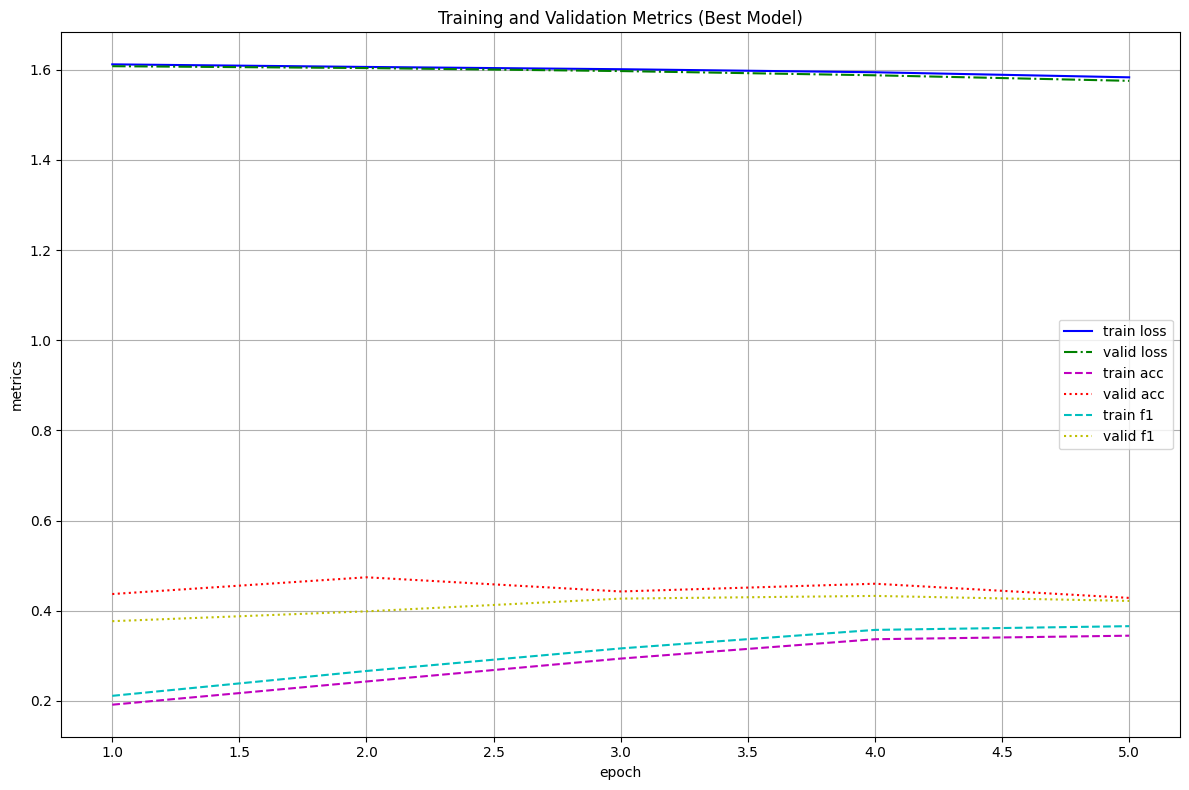

In [29]:
best_model = grid.best_estimator_

if hasattr(best_model, 'history_') and best_model.history_ is not None:
    # Print available metrics for debugging
    print("Available metrics:", best_model.history_[0].keys())
    
    epochs = list(range(1, len(best_model.history_) + 1))
    
    # Extract available metrics
    train_loss = [h.get('train_loss', None) for h in best_model.history_]
    valid_loss = [h.get('valid_loss', None) for h in best_model.history_]
    train_acc = [h.get('train_acc', None) for h in best_model.history_]
    valid_acc = [h.get('valid_acc', None) for h in best_model.history_]
    train_f1 = [h.get('train_f1', None) for h in best_model.history_]
    valid_f1 = [h.get('valid_f1', None) for h in best_model.history_]
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    plt.grid(True)
    
    # Plot metrics that exist
    if not all(x is None for x in train_loss):
        plt.plot(epochs, train_loss, 'b-', label='train loss')
    if not all(x is None for x in valid_loss):
        plt.plot(epochs, valid_loss, 'g-.', label='valid loss')
    if not all(x is None for x in train_acc):
        plt.plot(epochs, train_acc, 'm--', label='train acc')
    if not all(x is None for x in valid_acc):
        plt.plot(epochs, valid_acc, 'r:', label='valid acc')
    if not all(x is None for x in train_f1):
        plt.plot(epochs, train_f1, 'c--', label='train f1')
    if not all(x is None for x in valid_f1):
        plt.plot(epochs, valid_f1, 'y:', label='valid f1')
    
    plt.xlabel('epoch')
    plt.ylabel('metrics')
    plt.title('Training and Validation Metrics (Best Model)')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
else:
    print("Model history not found in the best estimator.")
    
    # If you want to see what's available
    if hasattr(best_model, 'history_'):
        print("History exists but might be empty or formatted differently.")
    else:
        print("No history_ attribute found on the best model.")

From the training loss, accuracy and weighted f1 charts, we can see that loss is falling slowly while accuracy and weighted f1 seem to have stabalised. 
However, we also know that as param search covered [5, 10], going to 10 epochs would have a lower weighted f1 than at 5 epochs. Hence we take the best model params as identified by hyper param tuning and cut the model at 5 epochs instead of training to an earlier cut off point. 

## Evaluation

In [18]:
# Evaluate best model
best_model = grid.best_estimator_
preds = best_model.predict(X_test.astype(np.float32))
probs = best_model.predict_proba(X_test.astype(np.float32))

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='macro')
report = classification_report(y_test, preds, target_names=label_encoder.classes_, digits=4)

print(f"FFNN Accuracy: {acc * 100:.2f}%")
print(f"FFNN Macro F1-score: {f1:.4f}")
print("\nClassification Report:\n", report)

FFNN Accuracy: 31.12%
FFNN Macro F1-score: 0.2931

Classification Report:
               precision    recall  f1-score   support

      center     0.1974    0.3659    0.2564        41
   lean left     0.3000    0.2459    0.2703        61
  lean right     0.1616    0.4324    0.2353        37
        left     0.7260    0.2387    0.3593       222
       right     0.2662    0.4868    0.3442        76

    accuracy                         0.3112       437
   macro avg     0.3302    0.3540    0.2931       437
weighted avg     0.4892    0.3112    0.3241       437



#### Classification Report Commentary

The FFNN using GloVe embeddings performs significantly worse compared to the FFNN with TD-IDF, achieving only 28.76% accuracy and a macro F1-score of 0.2796. This reflects a substantial drop in both overall predictive power and class-wise balance. 

This is inline with our expectations that an averaged of the GloVe embeddings would fail to capture the nuances needed for good separability across categories. 

### Confusion Matrices

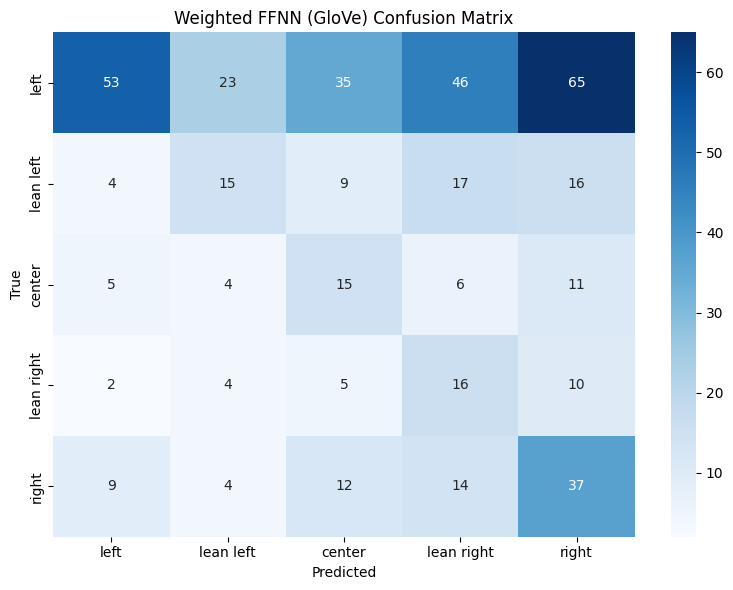

In [12]:
label_order = ['left', 'lean left', 'center', 'lean right', 'right']
label_indices = [np.where(label_encoder.classes_ == label)[0][0] for label in label_order]

#cm = confusion_matrix(y_test_np, y_pred, labels=label_indices)
cm = confusion_matrix(y_test, preds, labels=label_indices)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_order, yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Weighted FFNN (GloVe) Confusion Matrix')
plt.tight_layout()
plt.show()

- The FFNN with GloVe not only severely underperforms compared to FFNN with TF-IDF, it distinctively is unable to learn any clear class boundaries. It is evident that the average of the embeddings of an article does not meaningfully capture the bias in the article.

### ROC-AUC

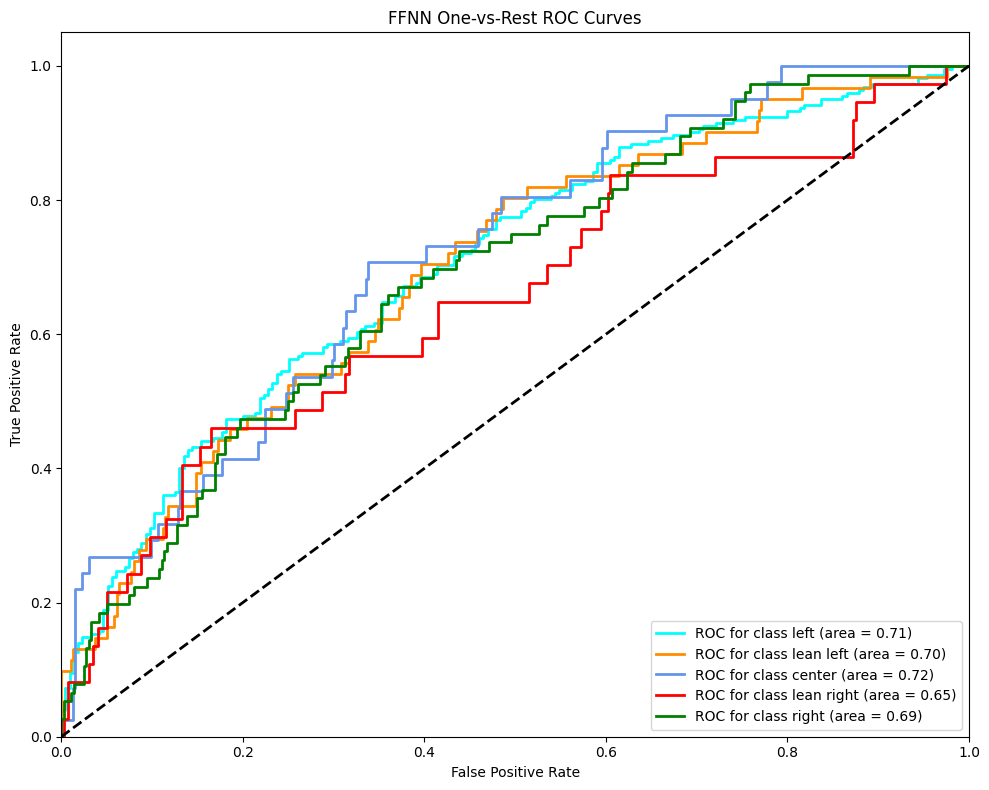

In [16]:
# ROC Curves
y_test_bin = label_binarize(y_test, classes=np.arange(output_dim))
probs = np.array(probs)
fpr = dict()
tpr = dict()
roc_auc = dict()

for label, idx in zip(label_order, label_indices):
    fpr[label], tpr[label], _ = roc_curve(y_test_bin[:, idx], probs[:, idx])
    roc_auc[label] = roc_auc_score(y_test_bin[:, idx], probs[:, idx])

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])

for label, color in zip(label_order, colors):
    plt.plot(fpr[label], tpr[label], color=color, lw=2,
             label=f'ROC for class {label} (area = {roc_auc[label]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FFNN One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
macro_auc = roc_auc_score(y_test_bin, probs, average='weighted')
print(f"Macro-weighted ROC AUC: {macro_auc:.4f}")

Macro-average ROC AUC: 0.6990


ROC-AUC values are moderate across all classes:
- Left: 0.71  
- Lean Left: 0.70
- Center: 0.72  
- Lean Right: 0.65  
- Right: 0.69  

The macro-average ROC-AUC for the FFNN with GloVe is 0.6990, indicating that the model achieves only modest separability between classes. While decision boundaries exist, they are much less distinct compared to the TD-IDF model, suggesting that the averaged GloVe embeddings do not capture class-specific differences effectively.

## Final Conclusion

### Performance Metrics Evaluation Summary

| Model Version | Accuracy (%) | Macro F1-score |
|---------------|--------------|----------------|
| Unweighted DT | 65.84        | 0.5658         |
| Weighted DT   | 60.22        | 0.5209         |
| Tuned DT      | 57.53        | 0.5762         |
| FFNN (TF-IDF) | 72.54        | 0.6109         |
| FFNN (GloVe)  | 31.12        | 0.2931         |

### Final Remarks

The FFNN with GloVe embeddings performs significantly worse than all other models so far, achieving only 28.76% accuracy and a macro F1-score of 0.2796. Unlike the FFNN (TF-IDF), which demonstrated strong class identification for major categories and maintained relatively balanced per-class performance, the GloVe model struggles both in overall prediction and minority class detection. 